# Experiment 3 — LoRA estimator variants

Testing other variants of GRPO.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

def read_results(experiment):
    files = sorted((ROOT / "results" / experiment).glob("*.json"))
    return [json.loads(path.read_text()) for path in files]

rows = read_results("03_lora_variants")
labels = {"grpo_constant": "GRPO-constant", "dr_grpo": "Dr. GRPO", "rft": "RFT", "maxrl": "MaxRL"}
order = ["GRPO-constant", "Dr. GRPO", "RFT", "MaxRL"]
samples = pd.DataFrame([{
    "variant": labels[row["config"]["name"].split("_lora_")[0]], "seed": row["config"]["seed"],
    "final": row["eval"][-1]["reward"], "format_rate": row["eval"][-1]["format_reward"],
} for row in rows])
summary = samples.groupby("variant").agg(final_mean=("final", "mean"), final_sd=("final", "std"), format_mean=("format_rate", "mean")).reindex(order)
summary.style.format({"final_mean": "{:.2%}", "final_sd": "{:.2%}", "format_mean": "{:.2%}"})

,final_mean,final_sd,format_mean
variant,,,
GRPO-constant,35.68%,1.37%,76.04%
Dr. GRPO,34.77%,2.17%,75.91%
RFT,32.94%,0.81%,79.82%
MaxRL,28.65%,3.18%,76.95%


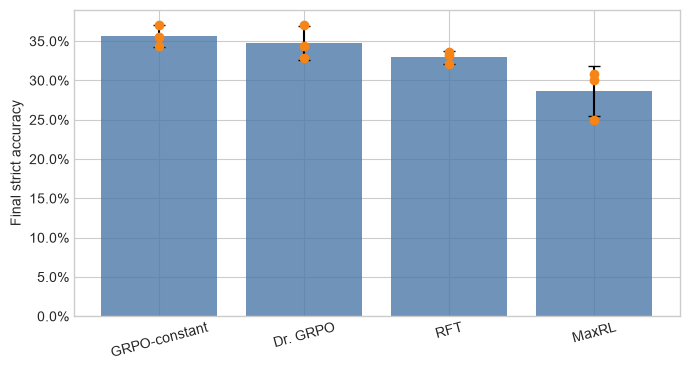

In [ ]:
fig, axis = plt.subplots(figsize=(7, 3.8))
x = range(len(summary))
axis.bar(x, summary.final_mean, yerr=summary.final_sd, capsize=4, color="#4C78A8", alpha=.8)
for index, name in enumerate(summary.index):
    axis.scatter([index] * len(samples[samples.variant == name]), samples.loc[samples.variant == name, "final"], color="#F58518", zorder=3)
axis.set(xticks=list(x), xticklabels=summary.index, ylabel="Final strict accuracy")
axis.yaxis.set_major_formatter(PercentFormatter(1)); axis.tick_params(axis="x", rotation=15); fig.tight_layout()
# fig.savefig(FIGURES / "03_lora_variants.png", dpi=180, bbox_inches="tight")